In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob, os, shutil, cv2, json, sys
from pathlib import Path

In [2]:
OPTIONS = json.loads(open('../../Task/info.json', 'r').read())
OPTIONS['dataset'] = Path().resolve().name
OPTIONS

{'dataset': 'Aquisition',
 'network': 'fasterrcnn',
 'img_size': 512,
 'n_aug': 1,
 'lr': 0.0001,
 'loss': 'classifier',
 'batch_size': 4,
 'scheduler': 'plateau',
 'epochs': 50,
 'score_threshold': 0.5,
 'nms_threshold': 0.3,
 'val_size': 0.1,
 'test_size': 0.1,
 'n_images': 0}

In [3]:
with open('../../Task/info.json', 'w', encoding='utf-8') as file:
    json.dump(OPTIONS, file, ensure_ascii=False, indent=4)

In [4]:
SOURCE  = 'files/DataBase.csv'
OUT_DIR = '../../Dataset/'
os.makedirs(OUT_DIR, exist_ok=True)

# CONVERTENDO ANOTAÇÕES

In [5]:
raw = pd.read_csv(SOURCE)
raw = raw.drop_duplicates(subset='path', keep='last')
print(f'{len(raw)} anotações')
raw.head()

84 anotações


,path,label,x_min,y_min,x_max,y_max,value
0,/home/klauss/Projects/DataScience/TrafficLight...,green,160,173,369,576,1
1,/home/klauss/Projects/DataScience/TrafficLight...,green,184,239,382,633,1
2,/home/klauss/Projects/DataScience/TrafficLight...,green,126,161,324,553,1
3,/home/klauss/Projects/DataScience/TrafficLight...,green,183,195,380,581,1
4,/home/klauss/Projects/DataScience/TrafficLight...,green,192,241,387,628,1


In [6]:
names  = [os.path.basename(path) for path in raw.path]
labels = [os.path.basename(os.path.dirname(path)) for path in raw.path]

df = pd.DataFrame({
    'path': [os.path.join(OPTIONS['dataset'], 'files', label, name) for label, name in zip(labels, names)],
    'label': labels,
    'x_min': raw.x_min.values, 'y_min': raw.y_min.values,
    'x_max': raw.x_max.values, 'y_max': raw.y_max.values,
})

print(len(df), 'imagens')
df.head()

84 imagens


,path,label,x_min,y_min,x_max,y_max
0,Aquisition/files/green/Screenshot from 2026-05...,green,160,173,369,576
1,Aquisition/files/green/Screenshot from 2026-05...,green,184,239,382,633
2,Aquisition/files/green/Screenshot from 2026-05...,green,126,161,324,553
3,Aquisition/files/green/Screenshot from 2026-05...,green,183,195,380,581
4,Aquisition/files/green/Screenshot from 2026-05...,green,192,241,387,628


In [7]:
missing = [path for path in df.path if not os.path.exists(os.path.join(OUT_DIR, path))]
print('imagens ausentes:', len(missing))
assert len(missing) == 0

df.to_csv(os.path.join(OUT_DIR, 'DataBase.csv'), index=False)
print('salvo em', os.path.join(OUT_DIR, 'DataBase.csv'), '-', len(df), 'linhas')

imagens ausentes: 0
salvo em ../../Dataset/DataBase.csv - 84 linhas


# CONFERINDO AS CAIXAS

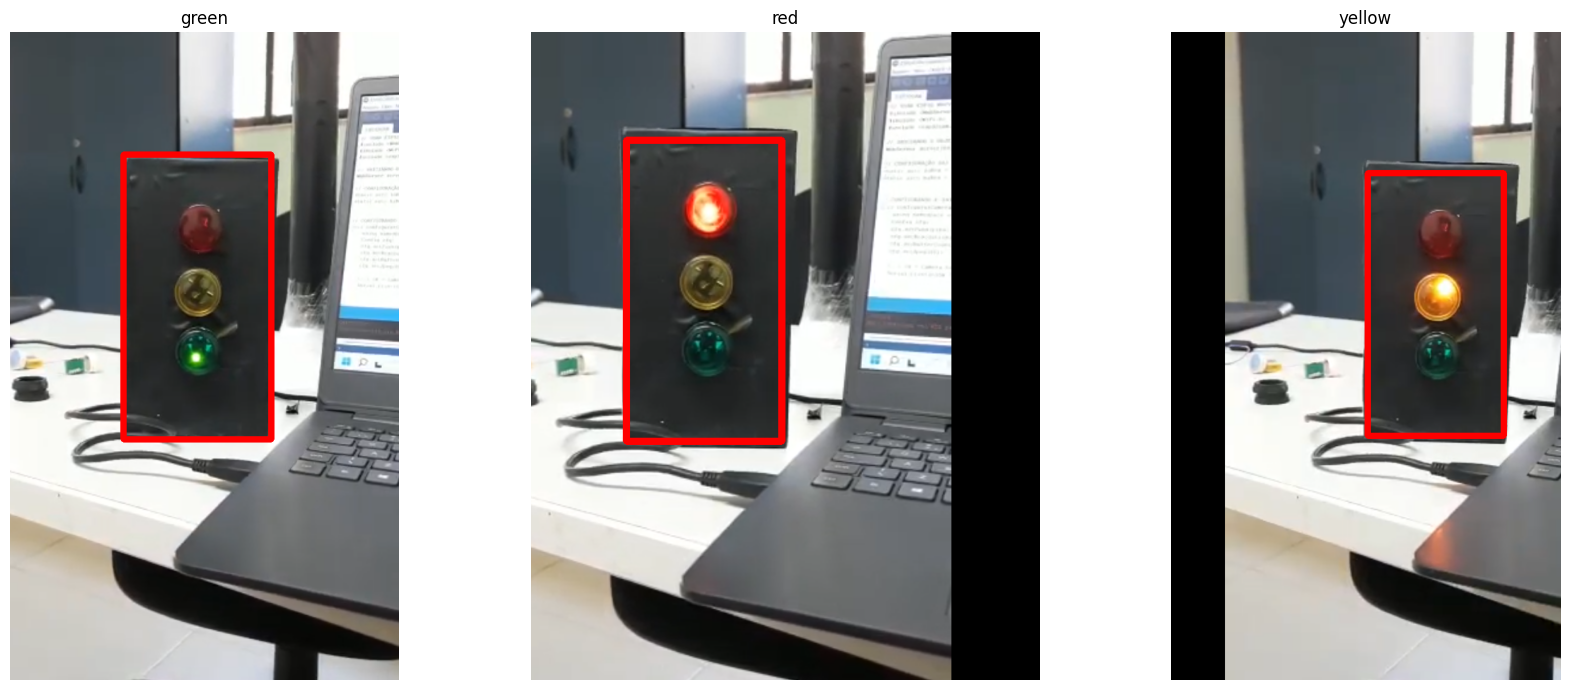

In [8]:
def showBoxes(ix, ax):
    row = df.iloc[ix]
    img = cv2.cvtColor(cv2.imread(os.path.join(OUT_DIR, row.path)), cv2.COLOR_BGR2RGB)
    cv2.rectangle(img, (int(row.x_min), int(row.y_min)), (int(row.x_max), int(row.y_max)), (255, 0, 0), 8)
    ax.imshow(img)
    ax.set_title(row.label)
    ax.axis('off')


fig, axes = plt.subplots(1, 3, figsize=(18, 7))
for ax, ix in zip(axes, [0, len(df) // 2, len(df) - 1]):
    showBoxes(ix, ax)

plt.tight_layout()
plt.show()